# Análisis de reseñas de `www.ticketmaster.co.uk`

Este notebook realiza un análisis completo con estos objetivos:

0. Extracción y Limpieza de datos
1. Analizar el **sentimiento global** de las reseñas.
2. Descubrir **topics**.
3. Medir **sentimiento por topic**.
4. Comparar topics vs otras empresas dentro de la misma categoría
5. Conclusiones


## 1) Librerías

Si te falta alguna librería, puedes instalarla con:

```bash
pip install pandas numpy scikit-learn transformers torch bertopic wordcloud matplotlib seaborn
```

In [1]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
from sklearn.preprocessing import MinMaxScaler
from transformers import pipeline
from bertopic import BERTopic

## 2) Configuración

- `MAX_ROWS`: limita filas para pruebas rápidas. Ponlo a `None` para usar todos los datos.
- `TARGET`: dominio de la compañía objetivo.
- `CAT`: sector de actividad de la compañía.
- `N_TOPICS`: número de temas a extraer.
- `TOP_WORDS`: número de palabras clave por topic.
- `MIN_TOPIC_DOCS`: mínimo de documentos para considerar un topic válido.

In [2]:
MAX_ROWS = None  # Ejemplo: 5000 para pruebas rápidas
TARGET = "www.ticketmaster.co.uk"
CAT = "Events & Entertainment"
N_TOPICS = 8
TOP_WORDS = 12
MIN_TOPIC_DOCS = 10

## 3) Carga de datos

Cargamos el dataset desde el CSV y lo convertimos a DataFrame.

In [3]:
df = pd.read_csv("data/trustpilot-reviews-123k.csv", nrows=MAX_ROWS)
print(f"Filas: {df.shape[0]} | Columnas: {df.columns.tolist()}")
df.head(3)

Filas: 123181 | Columnas: ['category', 'company', 'description', 'title', 'review', 'stars']


,category,company,description,title,review,stars
0,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Great quality dog drying robe although…,Great quality dog drying robe although had to ...,5
1,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Really prompt service,"Really prompt service, The sofa covers have no...",5
2,Animals & Pets,ruffandtumbledogcoats.com,At Ruff and Tumble we are proud to be the mark...,Life saver,I’ve purchased first of those coats in May2020...,5


## 4) Observamos qué tipo de caracteres hay

Antes de limpiar, exploramos qué nos vamos a encontrar en las reseñas: emojis, URLs, hashtags, saltos de línea, signos de puntuación, números, etc. Esto nos ayudará a construir una función de limpieza adecuada.

In [4]:
# Muestra aleatoria para ver con tus propios ojos qué contienen las reseñas
df['review'].sample(10).tolist()

['Very good service. Managed to retrieve the information/documents/photos etc from a broken laptop but not my internet bookmarks. ',
 'Highly recommendations for this company. Always have a best service. Quick deliveries and best customer service ever ✨',
 'Thank you to the Kingston Team for sorting the Dry Rot in our house. We had issues selling the property, and Kingston sorted the rot, allowing us to sell within a week. An amazing service! We recommend and endorse Kingston Preservation.',
 "The Company is great and replies to questions promptly and acts efficiently.However the delivery company it uses, DPD Local, is not good.  The plant arrived 2 days after it was due - and even that may be due to the Company chasing the deliverers.  My attempts to contact DPD Local failed - even when I reached the 'Speak to a representative' option nobody answered.  Attempts to email them also failed (though it is just possible that was down to my limited IT skills.)",
 "When you order, theres no m

count    123181.000000
mean        358.787305
std         314.553061
min          10.000000
25%         177.000000
50%         290.000000
75%         440.000000
max        9956.000000
Name: review, dtype: float64


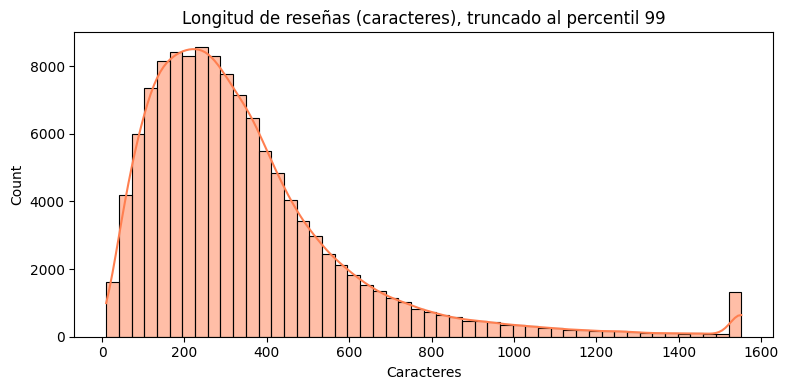

In [5]:
# Distribución de la longitud de las reseñas
rl = df["review"].astype(str).str.len()
print(rl.describe())

plt.figure(figsize=(8, 4))
sns.histplot(rl.clip(upper=rl.quantile(0.99)), bins=50, kde=True, color="coral")
plt.title("Longitud de reseñas (caracteres), truncado al percentil 99")
plt.xlabel("Caracteres")
plt.tight_layout()
plt.show()

#### Ver qué tipos de caracteres tenemos:

In [6]:
# ¿Hay URLs?
print("URLs:", df['review'].str.contains(r'http|www', na=False).sum())

# ¿Hay emojis?
print("Emojis:", df['review'].str.contains(r'[^\x00-\x7F]', na=False).sum())

# ¿Hay saltos de línea?
print("Saltos de línea:", df['review'].str.contains(r'\n', na=False).sum())

# ¿Hay hashtags?
print("Hashtags:", df['review'].str.contains(r'#\w+', na=False).sum())

# ¿Hay números?
print("Números:", df['review'].str.contains(r'\d', na=False).sum())

URLs: 16
Emojis: 34074
Saltos de línea: 0
Hashtags: 187
Números: 50327


### Conclusiones de la exploración

- **Emojis (34.074):** presentes en casi el 28% de las reseñas. Se eliminarán ya que para el análisis de texto trabajamos mejor con caracteres estándar.
- **Números (50.327):** muy frecuentes (fechas, precios, referencias). Se eliminarán por no aportar valor semántico.
- **URLs (16):** residuales, se eliminarán.
- **Hashtags (187):** pocos pero presentes. Se conservará la palabra eliminando solo el símbolo `#`.
- **Saltos de línea (0):** no hay, no es necesario tratarlos.

## 5) Función de limpieza

Con lo observado en el paso anterior, construimos una función de limpieza que aplicaremos a las reseñas.

In [7]:
def limpiar_texto(texto):
    if not isinstance(texto, str):
        return ""
    # Minúsculas
    texto = texto.lower()
    # Eliminar URLs
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    # Eliminar emojis y caracteres no ASCII
    texto = re.sub(r'[^\x00-\x7F]+', ' ', texto)
    # Conservar palabra de hashtags (quitar solo el #)
    texto = re.sub(r'#(\w+)', r'\1', texto)
    # Eliminar números
    texto = re.sub(r'\d+', '', texto)
    # Eliminar puntuación
    texto = re.sub(r'[^\w\s]', ' ', texto)
    # Eliminar espacios extra
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

# Verificación rápida
ejemplos = [
    "Great show! 😊 Paid £200 for tickets #concert www.ticketmaster.co.uk",
    "WORST experience EVER!!! Never buying from them again 😡",
    "Really good service, arrived in 2 days. Would recommend!"
]
for e in ejemplos:
    print("ANTES:   ", e)
    print("DESPUÉS: ", limpiar_texto(e))
    print()

ANTES:    Great show! 😊 Paid £200 for tickets #concert www.ticketmaster.co.uk
DESPUÉS:  great show paid for tickets concert

ANTES:    WORST experience EVER!!! Never buying from them again 😡
DESPUÉS:  worst experience ever never buying from them again

ANTES:    Really good service, arrived in 2 days. Would recommend!
DESPUÉS:  really good service arrived in days would recommend



La función de limpieza funciona correctamente. Elimina URLs, emojis, números 
y puntuación, conserva las palabras de los hashtags y convierte todo a minúsculas.
A continuación la aplicaremos a los datasets de Ticketmaster y la competencia.

## 6) Filtrado y separación de datos

Filtramos por sector y separamos las reseñas de Ticketmaster de las de la competencia.

In [8]:
# 1. Filtrar por sector
df_sector = df[df['category'] == CAT].copy()
print(f"Reseñas en el sector '{CAT}': {len(df_sector)}")
print(f"Empresas en el sector: {df_sector['company'].nunique()}")

# 2. Separar Ticketmaster y competencia
df_ticketmaster = df_sector[df_sector['company'] == TARGET].copy()
df_competencia  = df_sector[df_sector['company'] != TARGET].copy()
print(f"\nReseñas Ticketmaster: {len(df_ticketmaster)}")
print(f"Reseñas competencia: {len(df_competencia)}")

# 3. Verificación ANTES de limpiar
print("\n--- ANTES de limpiar ---")
print(df_ticketmaster['review'].head(3).tolist())

Reseñas en el sector 'Events & Entertainment': 5298
Empresas en el sector: 76

Reseñas Ticketmaster: 100
Reseñas competencia: 5198

--- ANTES de limpiar ---
['The Les Mis Spectacular is just that, spectacular! Fantastic show, with an amazing cast, only let down by Newcastle’s dreadfully outdated arena! £80-£90 to sit on small, hard plastic seats for 4hrs is a little insulting. ', 'Abba Voyage is a must it’s an excellent show but the venue and staff are amazingThey are happy dancing and polite which is not often the case at other venuesEasy to get to via DLR We used the little bar outside for food and drink beforehand all cooked to order and a glitter bar for those who want some glam plus a dance floor for your warm up moves ', 'Brilliant,  everything went smoothly and constantly informed through e mails regarding updates for event. Show was absolutely fantastic, the cast were brilliant, well worth the money and wait ']


In [9]:
# 4. Aplicar limpieza
df_ticketmaster['clean'] = df_ticketmaster['review'].apply(limpiar_texto)
df_competencia['clean']  = df_competencia['review'].apply(limpiar_texto)

# 5. Verificación DESPUÉS de limpiar
print("--- ANTES vs DESPUÉS de limpiar ---\n")
for i in range(3):
    print(f"Reseña {i+1}:")
    print(f"  ANTES:   {df_ticketmaster['review'].iloc[i][:150]}")
    print(f"  DESPUÉS: {df_ticketmaster['clean'].iloc[i][:150]}")
    print()

# 6. Guardar CSVs limpios
df_ticketmaster.to_csv('data/ticketmaster_reviews.csv', index=False)
df_competencia.to_csv('data/events_entertainment_reviews.csv', index=False)
print("\nCSVs guardados en data/")

--- ANTES vs DESPUÉS de limpiar ---

Reseña 1:
  ANTES:   The Les Mis Spectacular is just that, spectacular! Fantastic show, with an amazing cast, only let down by Newcastle’s dreadfully outdated arena! £80-£
  DESPUÉS: the les mis spectacular is just that spectacular fantastic show with an amazing cast only let down by newcastle s dreadfully outdated arena to sit on 

Reseña 2:
  ANTES:   Abba Voyage is a must it’s an excellent show but the venue and staff are amazingThey are happy dancing and polite which is not often the case at other
  DESPUÉS: abba voyage is a must it s an excellent show but the venue and staff are amazingthey are happy dancing and polite which is not often the case at other

Reseña 3:
  ANTES:   Brilliant,  everything went smoothly and constantly informed through e mails regarding updates for event. Show was absolutely fantastic, the cast were
  DESPUÉS: brilliant everything went smoothly and constantly informed through e mails regarding updates for event show wa

Los datos han sido separados y limpiados correctamente:
- **Ticketmaster:** 100 reseñas
- **Competencia:** 5.198 reseñas de 75 empresas del sector Events & Entertainment

Ambos datasets se han guardado en `data/` para su uso posterior.

## 7) Análisis de sentimiento

Usamos **DistilBERT**, una versión ligera y rápida de BERT, para clasificar cada reseña 
como positiva o negativa. El modelo tiene un límite de 512 tokens por reseña, 
por lo que truncamos textos más largos.

In [12]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

In [13]:
# Cargar modelo de sentimiento
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english",
    truncation=True,
    max_length=512
)

# Función que aplica el modelo a cada reseña
def analizar_sentimiento(texto):
    if not isinstance(texto, str) or texto.strip() == "":
        return "NEUTRAL", 0.0
    resultado = sentiment_pipeline(texto[:512])
    return resultado[0]['label'], resultado[0]['score']

# Test rápido antes de aplicar a todo
print("Test rápido:")
print(analizar_sentimiento("this show was absolutely amazing and fantastic"))
print(analizar_sentimiento("worst experience ever total disaster"))

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Test rápido:
('POSITIVE', 0.9998836517333984)
('NEGATIVE', 0.9997957348823547)


In [14]:
# Aplicar a Ticketmaster
print("Analizando Ticketmaster...")
df_ticketmaster[['sentiment', 'sentiment_score']] = df_ticketmaster['clean'].apply(
    lambda x: pd.Series(analizar_sentimiento(x))
)
print(f"✓ Ticketmaster listo: {len(df_ticketmaster)} reseñas")

# Aplicar a la competencia
print("Analizando competencia...")
df_competencia[['sentiment', 'sentiment_score']] = df_competencia['clean'].apply(
    lambda x: pd.Series(analizar_sentimiento(x))
)
print(f"✓ Competencia lista: {len(df_competencia)} reseñas")

Analizando Ticketmaster...
✓ Ticketmaster listo: 100 reseñas
Analizando competencia...
✓ Competencia lista: 5198 reseñas


In [15]:
# Resultados Ticketmaster
print("=== TICKETMASTER ===")
print(df_ticketmaster['sentiment'].value_counts())
print(f"\n% Positivo: {(df_ticketmaster['sentiment']=='POSITIVE').mean()*100:.1f}%")
print(f"% Negativo: {(df_ticketmaster['sentiment']=='NEGATIVE').mean()*100:.1f}%")

print("\n=== COMPETENCIA ===")
print(df_competencia['sentiment'].value_counts())
print(f"\n% Positivo: {(df_competencia['sentiment']=='POSITIVE').mean()*100:.1f}%")
print(f"% Negativo: {(df_competencia['sentiment']=='NEGATIVE').mean()*100:.1f}%")

=== TICKETMASTER ===
sentiment
NEGATIVE    75
POSITIVE    25
Name: count, dtype: int64

% Positivo: 25.0%
% Negativo: 75.0%

=== COMPETENCIA ===
sentiment
NEGATIVE    3290
POSITIVE    1908
Name: count, dtype: int64

% Positivo: 36.7%
% Negativo: 63.3%


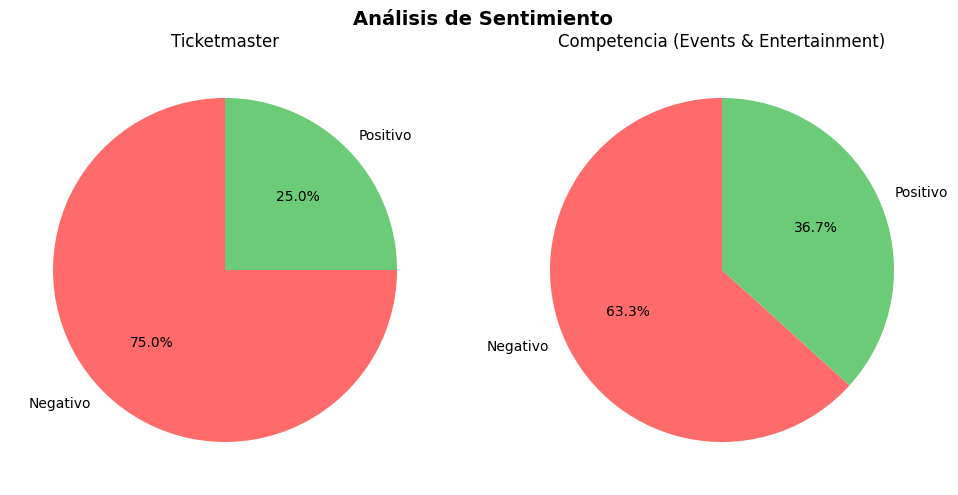

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Ticketmaster
axes[0].pie(
    df_ticketmaster['sentiment'].value_counts(),
    labels=['Negativo', 'Positivo'],
    colors=['#FF6B6B', '#6BCB77'],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Ticketmaster')

# Competencia
axes[1].pie(
    df_competencia['sentiment'].value_counts(),
    labels=['Negativo', 'Positivo'],
    colors=['#FF6B6B', '#6BCB77'],
    autopct='%1.1f%%',
    startangle=90
)
axes[1].set_title('Competencia (Events & Entertainment)')

plt.suptitle('Análisis de Sentimiento', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
diff = (df_ticketmaster['sentiment']=='NEGATIVE').mean()*100 - (df_competencia['sentiment']=='NEGATIVE').mean()*100
print(f"Diferencia: {diff:.1f} puntos porcentuales")

Diferencia: 11.7 puntos porcentuales


In [18]:
# Guardar con sentimiento incluido
df_ticketmaster.to_csv('data/ticketmaster_reviews.csv', index=False)
df_competencia.to_csv('data/events_entertainment_reviews.csv', index=False)
print("CSVs guardados con sentimiento ✓")

CSVs guardados con sentimiento ✓


### Conclusiones del análisis de sentimiento

- **Ticketmaster** presenta un **75% de reseñas negativas**, muy por encima de la media del sector.
- La **competencia** tiene un 63.3% de reseñas negativas, lo que indica que el sector en general 
  tiene margen de mejora, pero Ticketmaster está claramente por debajo.
- La diferencia de **11.7 puntos porcentuales** entre Ticketmaster y la competencia es significativa 
  y apunta a problemas específicos de la empresa que analizaremos en el topic modeling.

## 8) Topic modeling

Usamos BERTopic para descubrir los temas principales que aparecen en las reseñas.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(stop_words="english")

### Topics en Ticketmaster

In [24]:
topic_model_tm = BERTopic(
    language="english",
    nr_topics=5,        # Menos topics para 100 reseñas
    min_topic_size=5,   # Mínimo más pequeño
    vectorizer_model=vectorizer,
    verbose=True
)

topics_tm, probs_tm = topic_model_tm.fit_transform(df_ticketmaster['clean'].tolist())
df_ticketmaster['topic'] = topics_tm

print(topic_model_tm.get_topic_info())

2026-04-14 17:09:34,240 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

2026-04-14 17:09:37,577 - BERTopic - Embedding - Completed ✓
2026-04-14 17:09:37,578 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 17:09:37,653 - BERTopic - Dimensionality - Completed ✓
2026-04-14 17:09:37,654 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 17:09:37,662 - BERTopic - Cluster - Completed ✓
2026-04-14 17:09:37,663 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-14 17:09:37,685 - BERTopic - Representation - Completed ✓
2026-04-14 17:09:37,687 - BERTopic - Topic reduction - Reducing number of topics
2026-04-14 17:09:37,688 - BERTopic - Topic reduction - Number of topics (5) is equal or higher than the clustered topics(3).
2026-04-14 17:09:37,688 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-14 17:09:37,739 - BERTopic - Representation - Completed ✓


   Topic  Count                                 Name  \
0     -1     10      -1_ice_skating_event_experience   
1      0     45              0_alfie_boe_arena_venue   
2      1     45  1_tickets_ticketmaster_event_ticket   

                                      Representation  \
0  [ice, skating, event, experience, feel, people...   
1  [alfie, boe, arena, venue, seats, les, ball, a...   
2  [tickets, ticketmaster, event, ticket, app, ve...   

                                 Representative_Docs  
0  [this time was wrong as the entire team worked...  
1  [first off i chose this specific performance t...  
2  [i received an email hours prior to the show e...  


### Topics en la competencia

In [25]:
# Entrenamos BERTopic sobre la competencia
topic_model_comp = BERTopic(
    language="english",
    nr_topics=N_TOPICS,
    min_topic_size=MIN_TOPIC_DOCS,
    vectorizer_model=vectorizer,
    verbose=True
)

topics_comp, probs_comp = topic_model_comp.fit_transform(df_competencia['clean'].tolist())
df_competencia['topic'] = topics_comp

print(topic_model_comp.get_topic_info())

2026-04-14 17:11:44,807 - BERTopic - Embedding - Transforming documents to embeddings.


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/163 [00:00<?, ?it/s]

2026-04-14 17:12:14,874 - BERTopic - Embedding - Completed ✓
2026-04-14 17:12:14,876 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-14 17:12:15,999 - BERTopic - Dimensionality - Completed ✓
2026-04-14 17:12:16,000 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-14 17:12:16,145 - BERTopic - Cluster - Completed ✓
2026-04-14 17:12:16,146 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-14 17:12:16,312 - BERTopic - Representation - Completed ✓
2026-04-14 17:12:16,313 - BERTopic - Topic reduction - Reducing number of topics
2026-04-14 17:12:16,330 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-14 17:12:16,470 - BERTopic - Representation - Completed ✓
2026-04-14 17:12:16,472 - BERTopic - Topic reduction - Reduced number of topics from 78 to 8


   Topic  Count                                     Name  \
0     -1   1540           -1_tickets_ticket_service_time   
1      0   2148             0_tickets_ticket_refund_site   
2      1    611         1_delivery_ordered_order_service   
3      2    527             2_great_party_children_night   
4      3    191     3_server_support_pingperfect_service   
5      4    128          4_reading_readings_samira_scott   
6      5     38        5_date_experience_january_october   
7      6     15  6_vibrator_rabbit_pleasurable_materials   

                                      Representation  \
0  [tickets, ticket, service, time, refund, booki...   
1  [tickets, ticket, refund, site, email, money, ...   
2  [delivery, ordered, order, service, item, qual...   
3  [great, party, children, night, kids, amazing,...   
4  [server, support, pingperfect, service, server...   
5  [reading, readings, samira, scott, questions, ...   
6  [date, experience, january, october, april, no...   
7  [vibrato

In [26]:
df_ticketmaster.to_csv('data/ticketmaster_reviews.csv', index=False)
df_competencia.to_csv('data/events_entertainment_reviews.csv', index=False)
print("CSVs guardados con topics ✓")

CSVs guardados con topics ✓


## 9) Visualizaciones

Representamos gráficamente los resultados del análisis de sentimiento y los topics.

## 10) Conclusiones

Respondemos a las preguntas planteadas por el director de Customer Experience.